In [1]:
import pandas as pd
import os
from dotenv import load_dotenv

load_dotenv()

True

In [2]:
from lib.iux001 import fetch_data, aggregation_data,merging_data1
from lib.aux001 import calc_expression
from lib.cux001 import FactorEvaluate1 as FactorEvaluate1

In [3]:
method = 'bicso2'
instruments = 'rbb'
period = 5
task_id = '113001'
datasets = ['train','val']

In [4]:
bench_data = fetch_data(method=method,
                        instruments=instruments,
                        task_id=task_id,
                        datasets=datasets)

./records/bicso2/rbb/basic/train_data.feather
./records/bicso2/rbb/basic/val_data.feather
./records/bicso2/rbb/returns/train_returns.feather
./records/bicso2/rbb/returns/val_returns.feather


In [5]:
method = 'bicso3'
instruments = 'rbb'
period = 5
task_id = '113001'
datasets = ['train','val']

In [6]:
rearch_data = fetch_data(method=method,
                        instruments=instruments,
                        task_id=task_id,
                        datasets=datasets)

./records/bicso3/rbb/basic/train_data.feather
./records/bicso3/rbb/basic/val_data.feather
./records/bicso3/rbb/returns/train_returns.feather
./records/bicso3/rbb/returns/val_returns.feather


In [7]:
bench_data1 = bench_data[['trade_time','code','iv012_1_2_1']].set_index(
    ['trade_time','code']).unstack().shift(-1).stack().reset_index()

In [8]:
bench_data1

,trade_time,code,iv012_1_2_1
0,2011-01-04 09:17:00,RB,-0.000119
1,2011-01-04 09:18:00,RB,-0.000156
2,2011-01-04 09:19:00,RB,0.000023
3,2011-01-04 09:20:00,RB,-0.000208
4,2011-01-04 09:21:00,RB,0.000196
...,...,...,...
1010068,2024-02-21 09:49:00,RB,-0.000026
1010069,2024-02-21 09:50:00,RB,-0.000659
1010070,2024-02-21 09:51:00,RB,-0.000365
1010071,2024-02-21 09:52:00,RB,0.000017


In [9]:
cols = ['trade_time','code','nxt1_ret_1h','nxt1_ret_2h',
        'nxt1_ret_3h','nxt1_ret_5h','nxt1_ret_10h']
rearch_data1 = rearch_data[cols]

In [10]:
total_data1 = bench_data1.merge(rearch_data1, on=['trade_time','code']).sort_values(
    by=['trade_time','code'])

In [11]:
total_data2 = total_data1[[
    'trade_time','code','iv012_1_2_1','nxt1_ret_{0}h'.format(period)]]#.loc[1000:]

total_data2[total_data2['trade_time'] >= '2020-01-01 09:03:00']

,trade_time,code,iv012_1_2_1,nxt1_ret_5h
635953,2020-01-02 09:01:00,RB,-0.002552,-0.002040
635954,2020-01-02 09:02:00,RB,-0.001217,-0.002958
635955,2020-01-02 09:03:00,RB,-0.000394,-0.002749
635956,2020-01-02 09:04:00,RB,0.000086,-0.001965
635957,2020-01-02 09:05:00,RB,0.000872,-0.000183
...,...,...,...,...
950504,2024-02-21 09:49:00,RB,-0.000026,-0.000696
950505,2024-02-21 09:50:00,RB,-0.000659,-0.000481
950506,2024-02-21 09:51:00,RB,-0.000365,-0.000486
950507,2024-02-21 09:52:00,RB,0.000017,-0.000403


In [12]:
#expression = "MRANK(240,MRANK(240,'tc003_2_3_1'))"
expression = "MA(10,'iv012_1_2_1')"

In [13]:
total_data1

,trade_time,code,iv012_1_2_1,nxt1_ret_1h,nxt1_ret_2h,nxt1_ret_3h,nxt1_ret_5h,nxt1_ret_10h
0,2011-02-01 09:03:00,RB,-0.000387,0.000402,0.000499,-0.000043,-0.000608,-0.001203
1,2011-02-01 09:04:00,RB,-0.000150,0.000098,-0.000445,-0.001184,-0.001277,-0.001665
2,2011-02-01 09:05:00,RB,-0.000347,-0.000542,-0.001281,-0.001108,-0.001672,-0.001994
3,2011-02-01 09:06:00,RB,0.000022,-0.000739,-0.000566,-0.000832,-0.001643,-0.001670
4,2011-02-01 09:07:00,RB,0.000573,0.000173,-0.000093,-0.000391,-0.000766,-0.000382
...,...,...,...,...,...,...,...,...
950504,2024-02-21 09:49:00,RB,-0.000026,0.000251,0.000445,0.000043,-0.000696,-0.000160
950505,2024-02-21 09:50:00,RB,-0.000659,0.000194,-0.000208,-0.000993,-0.000481,0.000072
950506,2024-02-21 09:51:00,RB,-0.000365,-0.000401,-0.001186,-0.001141,-0.000486,0.000047
950507,2024-02-21 09:52:00,RB,0.000017,-0.000785,-0.000739,-0.000273,-0.000403,0.000459


In [14]:
%%time
factor_data1 = calc_expression(expression=expression,
                              total_data=total_data1[['trade_time','code','iv012_1_2_1']].set_index('trade_time'))

CPU times: user 18.1 s, sys: 990 ms, total: 19.1 s
Wall time: 19.1 s


In [15]:
dt = merging_data1(factor_data=factor_data1,
                      returns_data=total_data1,
                      period=period)

In [16]:
dt.tail(10)

,trade_time,transformed,code,nxt1_ret_5h
950498,2024-02-21 09:44:00,-0.000178,RB,0.001442
950499,2024-02-21 09:45:00,-0.000141,RB,0.001240
950500,2024-02-21 09:46:00,-0.000155,RB,0.001582
950501,2024-02-21 09:47:00,-0.000186,RB,0.000674
950502,2024-02-21 09:48:00,-0.000213,RB,-0.000274
950503,2024-02-21 09:49:00,-0.000191,RB,-0.000696
950504,2024-02-21 09:50:00,-0.000187,RB,-0.000481
950505,2024-02-21 09:51:00,-0.000146,RB,-0.000486
950506,2024-02-21 09:52:00,-0.000151,RB,-0.000403
950507,2024-02-21 09:53:00,-0.000124,RB,0.000281


In [17]:
evaluate1 = FactorEvaluate1(factor_data=dt,
                                factor_name='transformed',
                                ret_name='nxt1_ret_{0}h'.format(period),
                                roll_win=15,
                                fee=0.0,
                                scale_method='roll_zscore',
                                expression=expression,
                                resampling_win=period)

In [18]:
stats_dt = evaluate1.run()

In [19]:
stats_dt

{'total_ret': 12.8114782938247,
 'avg_ret': 2.225965873959928e-05,
 'max_dd': -0.38611147413196256,
 'calmar': 0.38224251890291844,
 'sharpe1': 0.0033242207567464005,
 'sharpe2': 0.33376830065769525,
 'turnover': 0.42915671944400446,
 'win_rate': 0.5153117092006476,
 'profit_ratio': 1.100712417094862,
 'total_ic': 0.005839339197811546,
 'ic_mean': 0.03978115673160989,
 'ic_std': 0.2632117950800203,
 'ic_ir': 0.1511374394126822,
 'factor_autocorr': 0.572629028447767,
 'ret_autocorr': -0.00794088242310884}

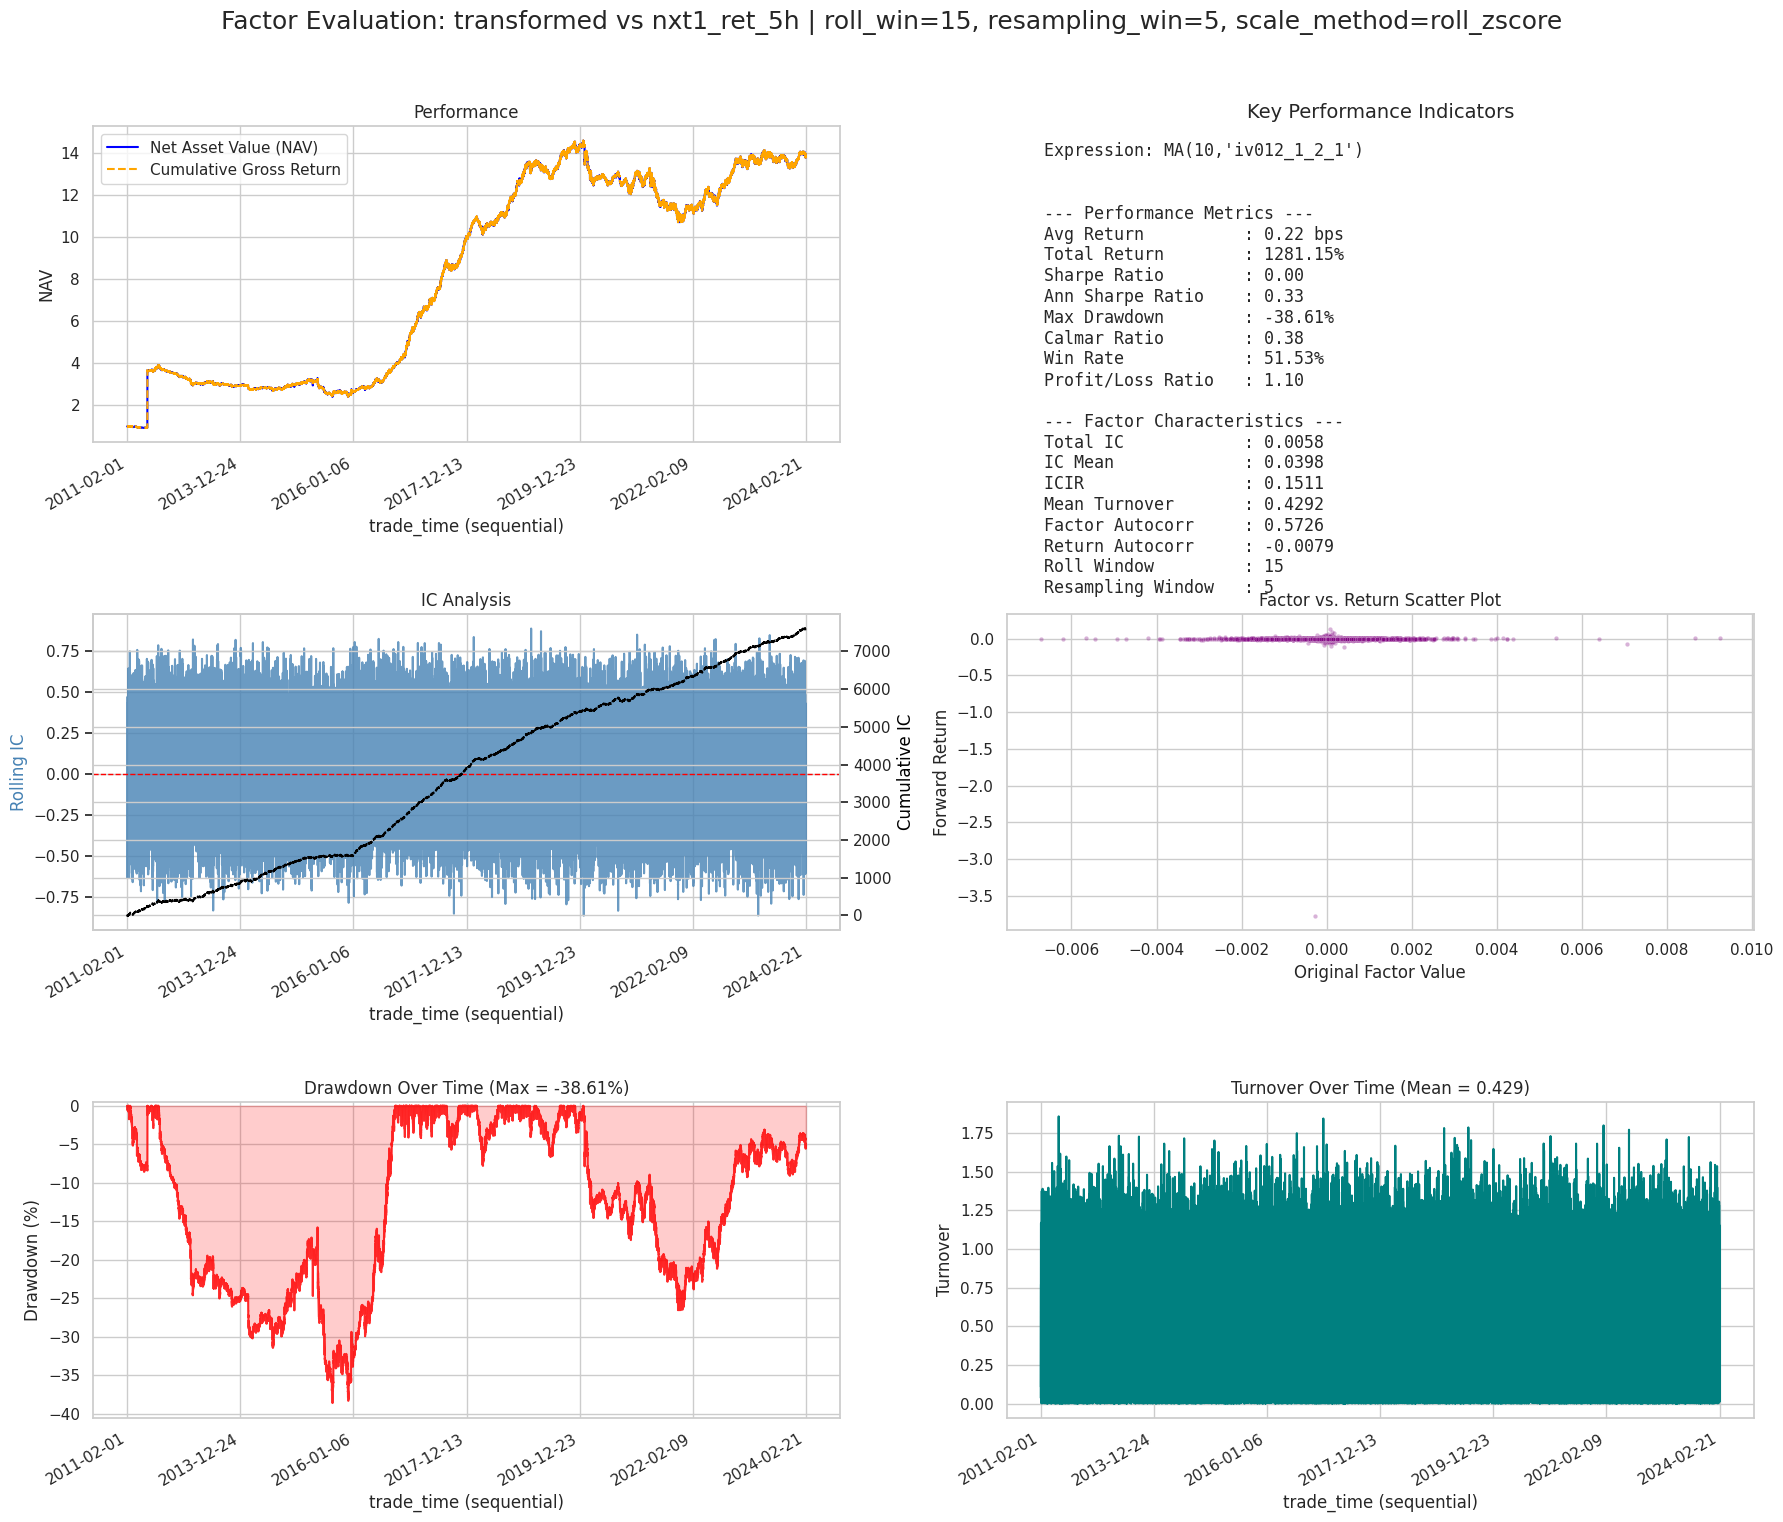

In [20]:
evaluate1.plot_results()